<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-Raygarza1243/blob/main/Ray_Garza_OOP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 21: Object-Oriented Programming

## Learning Objectives
By the end of this module you should be able to:
1. Explain the OOP concepts of **encapsulation**, **attributes**, and **methods**
2. Recognize that Python objects already use dot notation for data and methods
3. Define a class with `__init__`, an internal method, and an external method
4. Explain the role of `self` in a class definition
5. Use **inheritance** to extend a parent class with `super()` and method overriding
6. Build a new class by inheriting from an existing one and adding only what is new

---

## Background: Two Programming Paradigms

So far in this course we have been following **procedural programming** — we think of our code as a sequence of steps, introducing new variables for every task. For short scripts this is fine, but for larger projects it becomes unwieldy.

**Object-Oriented Programming (OOP)** reorganizes code around *objects* that bundle related data and functions together. For example, if we simulate two cats, instead of `x_cat1`, `v_cat1`, `x_cat2`, `v_cat2` scattered throughout our code, OOP lets us write `cat1.x`, `cat1.v`, `cat2.x`, `cat2.v` — the data lives *inside* its object. This is called **encapsulation**.

The variables attached to an object are its **attributes** (sometimes called *data fields* or *properties*). The functions attached to an object are its **methods**. We access both using dot notation: `cat1.run(velocity=1)`, `cat1.weight`.

The key insight: **everything in Python is already an object**, so you have been using OOP all along.

---

## Section 0: Objects You Already Know

> **Q0.1** — Run the two cells below. For the complex number `a = 2+3j`, identify one *attribute* (data) and one *method* you can call on it.

> **Q0.2** — For the NumPy array `a = np.eye(4)`, identify two attributes and two methods. How would you call them using dot notation?

In [43]:
# A complex number is an object
a = 2.0 + 3j

print("Real part (attribute):", a.real)
print("Imaginary part (attribute):", a.imag)
print("Conjugate (method):", a.conjugate())
print("Memory size (method):", a.__sizeof__())

Real part (attribute): 2.0
Imaginary part (attribute): 3.0
Conjugate (method): (2-3j)
Memory size (method): 32


In [44]:
import numpy as np

# A NumPy array is an object
a = np.eye(4)

print("Shape (attribute):", a.shape)
print("Dtype (attribute):", a.dtype)
print("Flattened (method):")
print(a.flatten())

Shape (attribute): (4, 4)
Dtype (attribute): float64
Flattened (method):
[1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1.]


*Your answers to Q0.1 and Q0.2:*

In [ ]:
# Attribute (a.real, return 2.0), method (a.conjugate, returns (2-3j))
# Attribute (a.shape, returns(4, 4)), (a.dtype, returns float64), method (a.flatten(), return flatten array), (a.transpose(), returns transpose array)

---

## Part 1: Building the `Line` Class

We will create `Line` objects. Each line is described by $y = c_0 + c_1 x$, where $c_0$ is the intercept and $c_1$ is the slope. We want to:
1. Store $c_0$ and $c_1$ as attributes
2. Compute $y$ values with an internal method `__calc__`
3. Return $(x, y)$ arrays over a range with a public method `table`

Here is how we *want* to use the class once it is defined:

```python
L1 = Line(c0=1, c1=2)
L2 = Line(c0=0.5, c1=2.5)
print(L1.c1, L1.c0)           # access attributes
plt.plot(*L1.table(0, 10, 20), 'bo')  # call a method
```

### Task 1 — Write the `Line` class

> **Q1.1** — Fill in the `# TODO` in `__calc__` to return the correct $y$ value using `self.c0` and `self.c1`.

> **Q1.2** — What is `self`? Why can't we write `c0 = c0` inside `__init__` instead of `self.c0 = c0`?

> **Q1.3** — The method `__calc__` uses double underscores. What Python convention does this signal? Why would we hide this method rather than making it public?

In [45]:
import numpy as np
import matplotlib.pyplot as plt

class Line():
    def __init__(self, c0, c1):
        self.c0 = c0
        self.c1 = c1

    def __calc__(self, x):
        y = self.c0 + self.c1 * x
        return y

    def table(self, L=0, R=20, n=100):
        x = np.linspace(L, R, n)
        y = self.__calc__(x)
        return x, y

L1: slope=2, intercept=1
L2: slope=2.5, intercept=0.5


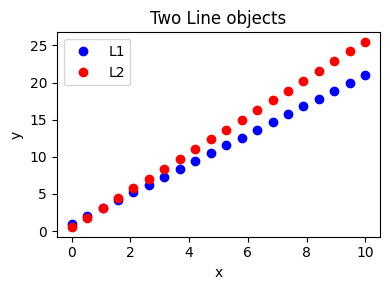

In [46]:
# Test the Line class
L1 = Line(c0=1, c1=2)
L2 = Line(c0=0.5, c1=2.5)

print(f"L1: slope={L1.c1}, intercept={L1.c0}")
print(f"L2: slope={L2.c1}, intercept={L2.c0}")

plt.figure(figsize=(4, 3))
plt.plot(*L1.table(0, 10, 20), 'bo', label='L1')
plt.plot(*L2.table(0, 10, 20), 'ro', label='L2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Two Line objects')
plt.legend()
plt.tight_layout()
plt.show()

*Your answers to Q1.1, Q1.2, and Q1.3:*

In [ ]:
# self is a instance reference. We can't write c0 = c0 because it would not create an instance on itself. self.c0 = c0 assigns onto self making the instance.
# The _calc_ promotes encapsulation, it can be changed in the future without breaking the code.

---

## Part 2: Inheritance — the `Parabola` Class

**Inheritance** lets a new class (the *child*) reuse everything already defined in an existing class (the *parent*) and only add or override what is different. The syntax is:

```python
class Child(Parent):
    ...
```

Inside the child, `super()` refers to the parent class, so `super().__init__(...)` calls the parent's initializer.

For a parabola $y = c_0 + c_1 x + c_2 x^2$:
- We inherit $c_0$, $c_1$, and `table()` from `Line`
- We only need to add $c_2$ and override `__calc__`

### Task 2 — Read and run the `Parabola` class

> **Q2.1** — In `Parabola.__init__`, why do we call `super().__init__(c0, c1)` first?

> **Q2.2** — The `table()` method is **not** redefined in `Parabola`. How does it still work correctly? What does this tell you about how `__calc__` gets resolved when `table()` calls `self.__calc__(x)`?

> **Q2.3** — Run the plotting cell. Describe what the three curves look like and verify that the shapes are correct.

L1 degree: 2,  P1 degree: 3


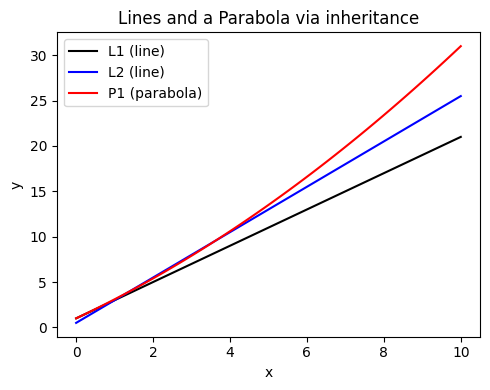

In [47]:
import numpy as np
import matplotlib.pyplot as plt

class Line():
    def __init__(self, c0, c1):
        self.c0 = c0
        self.c1 = c1
        self.D  = 2    # degree

    def __calc__(self, x):
        return self.c0 + self.c1 * x

    def table(self, L=0, R=20, n=100):
        x = np.linspace(L, R, n)
        y = self.__calc__(x)
        return x, y

    @property
    def degree_name(self):
        if self.D == 2:
            return 'linear'
        elif self.D == 3:
            return 'quadratic'
        elif self.D == 4:
            return 'cubic'
        else:
            return f'polynomial degree {self.D}'


class Parabola(Line):
    def __init__(self, c0, c1, c2):
        super().__init__(c0, c1)   # inherit c0, c1 from Line
        self.c2 = c2
        self.D  = 3                # update degree

    def __calc__(self, x):
        return super().__calc__(x) + self.c2 * x**2

# Create instances
L1 = Line(c0=1,   c1=2)
L2 = Line(c0=0.5, c1=2.5)
P1 = Parabola(c0=1, c1=2, c2=0.1)

print(f"L1 degree: {L1.D},  P1 degree: {P1.D}")

plt.figure(figsize=(5, 4))
plt.plot(*L1.table(0, 10, 50), 'k-', label='L1 (line)')
plt.plot(*L2.table(0, 10, 50), 'b-', label='L2 (line)')
plt.plot(*P1.table(0, 10, 50), 'r-', label='P1 (parabola)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lines and a Parabola via inheritance')
plt.legend()
plt.tight_layout()
plt.show()

*Your answers to Q2.1, Q2.2, and Q2.3:*

In [ ]:
# We call super()._init_(c0, c1) to first initialize c0 and c1.
# The table () is not refinded because it comes from the Line class.
# L1 is a straight line, L2 is also a straight line but with a steeper slope, and L3 is a parabola curve.

---

## Part 3: Task — Build a `Cubic` Class

A cubic polynomial is $y = c_0 + c_1 x + c_2 x^2 + c_3 x^3$.

### Task 3 — Implement `Cubic` by inheriting from `Parabola`

> **Q3.1** — Fill in the `Cubic` class below. You only need to:
> 1. Pass `c0`, `c1`, `c2` to `Parabola` via `super().__init__`
> 2. Store `c3` as a new attribute
> 3. Override `__calc__` to add the $c_3 x^3$ term

> **Q3.2** — Does `Cubic` need to define a `table()` method? Explain why or why not.

> **Q3.3** — Create `C1 = Cubic(c0=1, c1=0, c2=-1, c3=0.1)` and plot it alongside `P1` over $x \in [0, 10]$. What is `C1.D`?

In [48]:
class Cubic(Parabola):
    def __init__(self, c0, c1, c2, c3):
        super().__init__(c0, c1, c2
                         )
        self.c3 = c3
        self.D  = 4     # degree

    def __calc__(self, x):
        return super().__calc__(x) + self.c3 * x**3

C1 degree: 4


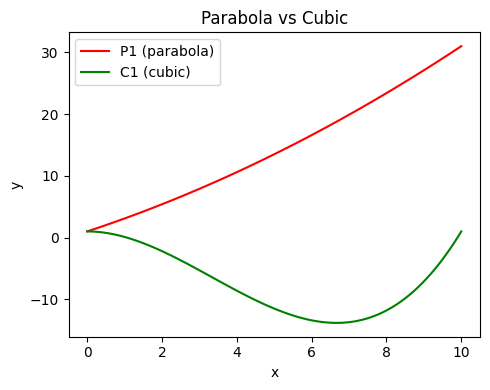

In [49]:
# Test your Cubic class
C1 = Cubic(c0=1, c1=0, c2=-1, c3=0.1)
print(f"C1 degree: {C1.D}")

plt.figure(figsize=(5, 4))
plt.plot(*P1.table(0, 10, 100), 'r-', label='P1 (parabola)')
plt.plot(*C1.table(0, 10, 100), 'g-', label='C1 (cubic)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Parabola vs Cubic')
plt.legend()
plt.tight_layout()
plt.show()

*Your answers to Q3.1, Q3.2, and Q3.3:*

In [ ]:
# No, Cubic does not need the table() method. table() method comes from the Line class
# c1.D = 4

---

## Part 4: Exploration

### Task 4 — Find intersection points

> **Q4.1** — Use `table()` with a fine grid (`n=10000`) to find the approximate $x$ values where `P1` and `C1` cross (i.e., where `|y_P1 - y_C1|` is smallest). Print the intersection point(s).

> **Q4.2** — Add a `degree_name` property to `Line` that returns a human-readable string: `'linear'` for degree 2, `'quadratic'` for degree 3, `'cubic'` for degree 4. You only need to modify `Line` — the subclasses get it for free. Verify with `L1.degree_name`, `P1.degree_name`, `C1.degree_name`.

In [50]:
# Task 4.1 — find where P1 and C1 intersect
x_vals, y_P1 = P1.table(0, 10, 10000)
_,       y_C1 = C1.table(0, 10, 10000)

diff = np.abs(y_P1 - y_C1)
min_diff_indices = np.where(diff == np.min(diff))

print("Approximate intersection point(s):")
for idx in min_diff_indices[0]:
    print(f"x = {x_vals[idx]:.4f}, y_P1 = {y_P1[idx]:.4f}, y_C1 = {y_C1[idx]:.4f}")




Approximate intersection point(s):
x = 0.0000, y_P1 = 1.0000, y_C1 = 1.0000


In [51]:
print(f"L1 degree name: {L1.degree_name}")
print(f"P1 degree name: {P1.degree_name}")
print(f"C1 degree name: {C1.degree_name}")

L1 degree name: linear
P1 degree name: quadratic
C1 degree name: cubic


---

## Summary Questions

> **S1** — In your own words, explain the difference between a *class* and an *instance* (object). Use `Line` and `L1` as examples.

> **S2** — What is `self`? If Python were to rewrite `L1.table(0, 10, 20)` as a regular function call, what would it look like? (Hint: what is the hidden first argument?)

> **S3** — Suppose you want a `Quartic` class for $y = c_0 + c_1 x + c_2 x^2 + c_3 x^3 + c_4 x^4$. Which class should it inherit from? Write the minimum code needed (just `__init__` and `__calc__`).

> **S4** — Describe one situation in physics simulation (other than polynomial curves) where building a class hierarchy with inheritance would make your code more organized.

In [ ]:
# A class is a template for creating objects, Line class defines c0, c1, table(), an instance is a specific entity created from that template, L1 instance with c0 = 1 and c1 = 2.
# self is a reference from the instance, If L1.table(0, 10, 20) were rewritten, it would look like Line.table(L1, 0, 10, 20).
# A Quartic class will inherit from a Cubic class.
# A class hierarchy would help for simulating celestial bodies and gravitinal force.

In [ ]:
# Code for Q3
class Quartic(Cubic):
    def __init__(self, c0, c1, c2, c3, c4):
        super().__init__(c0, c1, c2, c3) # Inherit up to c3 from Cubic
        self.c4 = c4
        self.D  = 5                       # Update degree

    def __calc__(self, x):
        return super().__calc__(x) + self.c4 * x**4